In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cards_df = pd.read_csv('./data/cards_clustered.csv')
decks_df = pd.read_csv('./data/decks.csv')

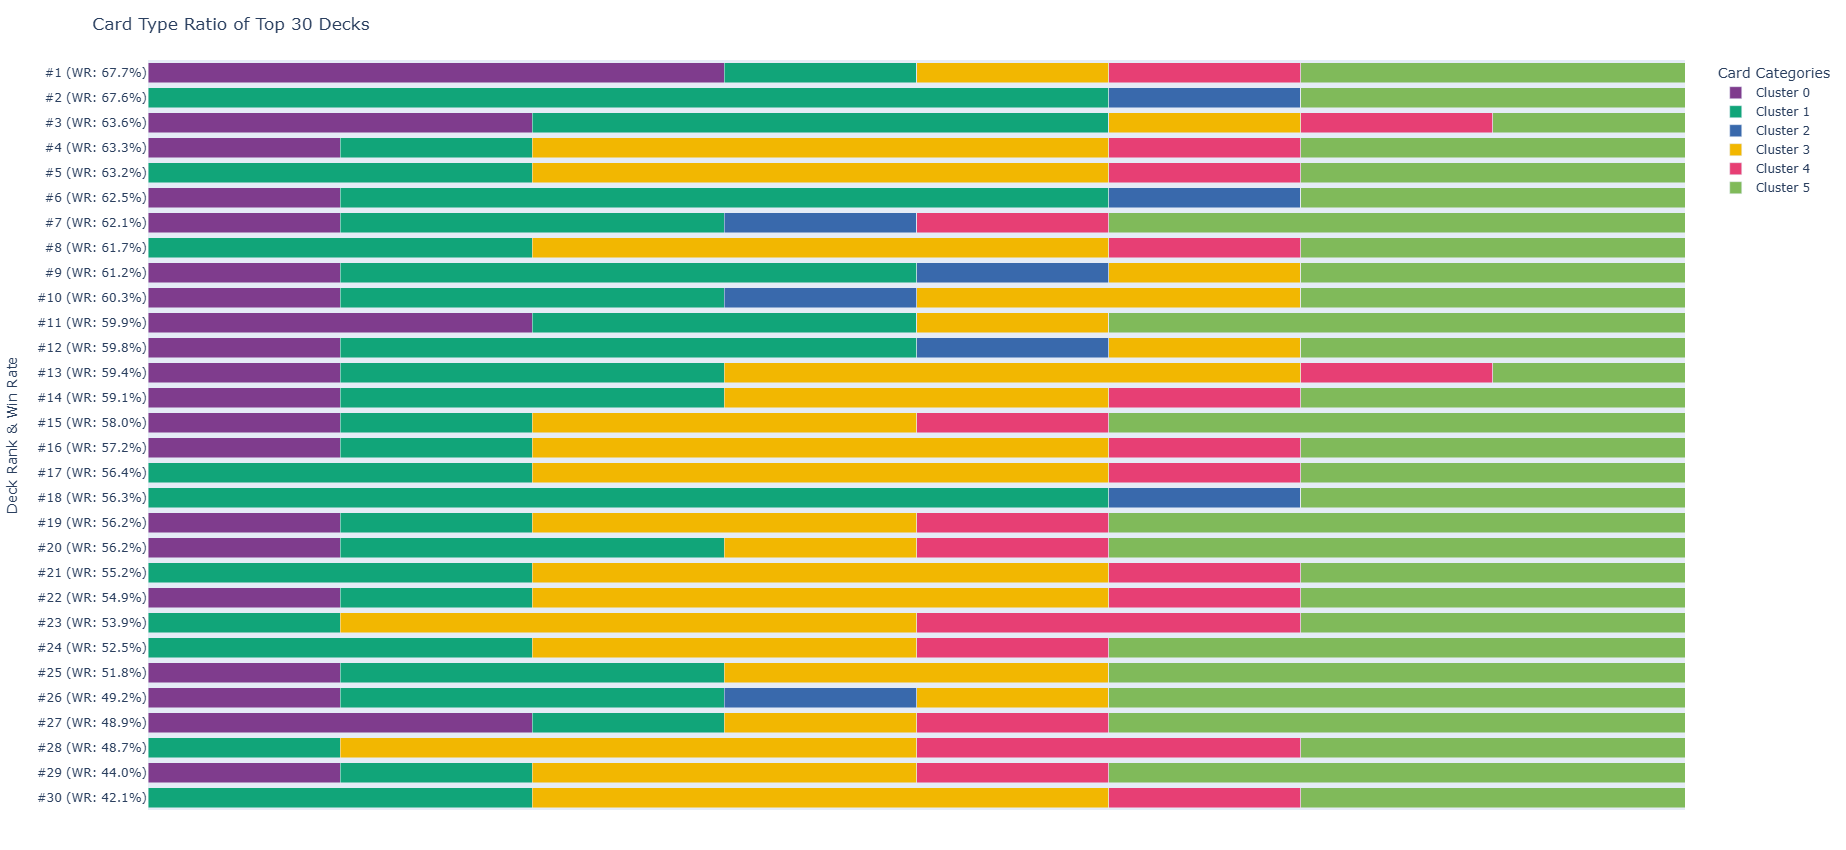

In [3]:
# Bar Chart of Deck Ratios
card_to_cluster = dict(zip(cards_df['name'], cards_df['Cluster']))
deck_clusters = decks_df.iloc[:, :8].map(lambda x: card_to_cluster.get(x, np.nan))

cluster_counts = deck_clusters.apply(lambda row: row.value_counts(), axis=1).fillna(0).astype(int)
cluster_counts = cluster_counts.reindex(columns=sorted(cluster_counts.columns))
cluster_counts.columns = [f"Cluster {int(c)}" for c in cluster_counts.columns]

cluster_ratios = cluster_counts.div(8)

decks_sorted = decks_df.sort_values(by='Win Rate', ascending=False).reset_index(drop=True)
cluster_ratios['Deck'] = [f"#{i+1} (WR: {row['Win Rate']}%)" for i, row in decks_sorted.iterrows()]

df_long = cluster_ratios.melt(id_vars='Deck', var_name='Cluster', value_name='Ratio')

fig = px.bar(
    df_long, 
    x='Ratio', 
    y='Deck', 
    color='Cluster', 
    orientation='h',
    title='Card Type Ratio of Top 30 Decks',
    labels={'Deck': 'Deck Rank & Win Rate'},
    category_orders={'Deck': cluster_ratios['Deck']} ,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(
    barmode='stack',
    height=850,
    xaxis=dict(visible=False, range=[0, 1]),
    margin=dict(l=120, r=40, t=60, b=40),
    legend_title_text='Card Categories',
    hovermode='y unified'
)

#fig.write_html('./graphs/card_type_ratio.html')
fig.show()

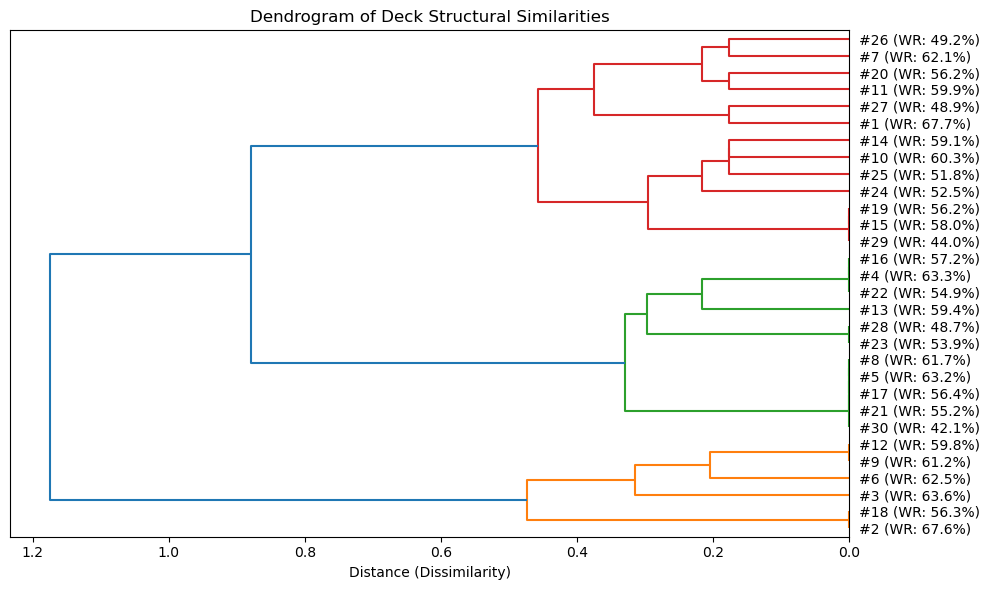

In [4]:
# Hierarchical clustering
features = cluster_ratios.drop(columns=['Deck'])

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(features, method='ward'), 
                            labels=cluster_ratios['Deck'].tolist(),
                            orientation='left')

plt.title('Dendrogram of Deck Structural Similarities')
plt.xlabel('Distance (Dissimilarity)')
plt.tight_layout()
#plt.savefig('./graphs/deck_dendrogram.png')
plt.show()

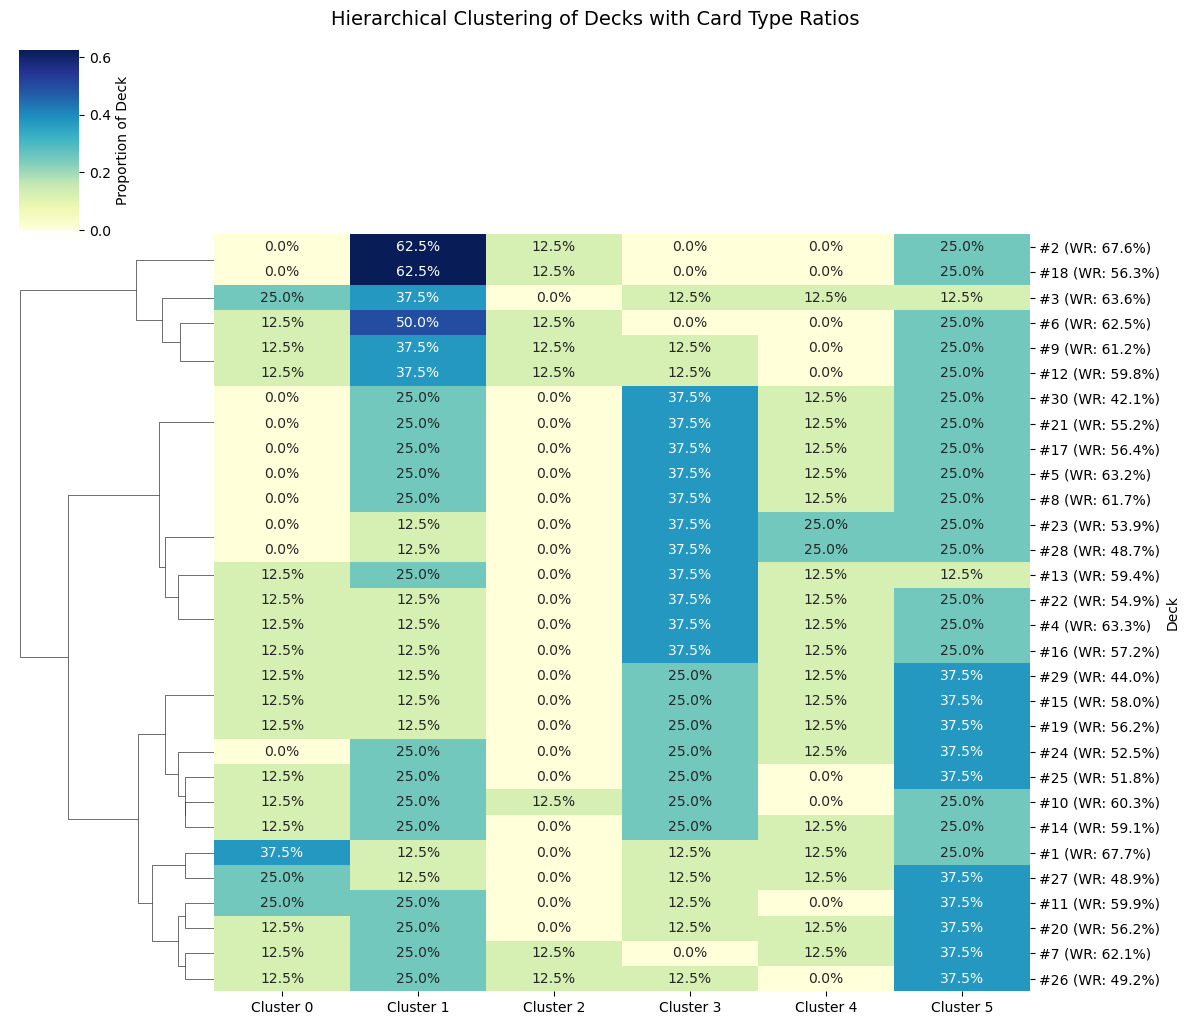

In [5]:
# 1. Prepare the data: Set the Deck labels as the index so they label the rows
heatmap_data = cluster_ratios.set_index('Deck')

# 2. Generate the clustermap
# We set col_cluster=False because we only want to cluster the decks (rows), 
# keeping your card clusters ordered sequentially (Cluster 0, 1, 2...).
g = sns.clustermap(
    heatmap_data,
    method='ward',
    metric='euclidean',
    col_cluster=False,       # Keeps your card clusters in order
    row_cluster=True,        # Clusters your 30 decks hierarchically
    cmap='YlGnBu',           # Consistent color palette
    annot=True,              # Injects the actual card ratio numbers into the grid
    fmt='.1%',               # Formats the grid numbers as percentages
    figsize=(12, 10),
    cbar_kws={'label': 'Proportion of Deck'}
)

# Adjust layout to prevent label clipping
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
g.fig.suptitle('Hierarchical Clustering of Decks with Card Type Ratios', y=1.02, fontsize=14)

#g.savefig('./graphs/deck_clustermap.png', bbox_inches='tight')
plt.show()

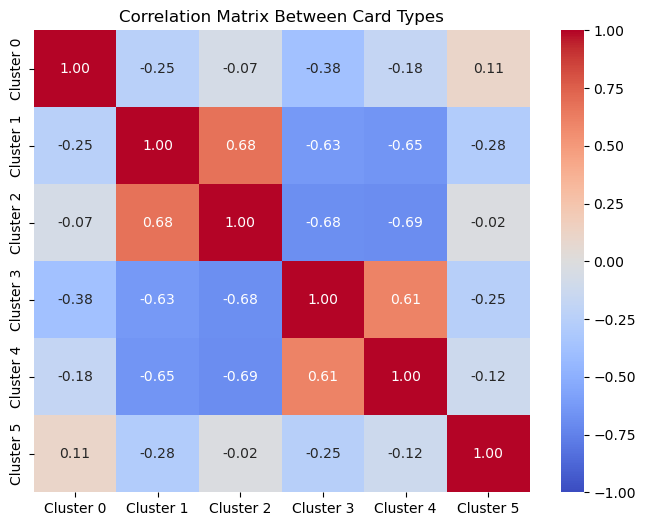

In [6]:
# Compute Pearson correlation between the different clusters
corr_matrix = cluster_ratios.drop(columns=['Deck']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix Between Card Types')
#plt.savefig('./graphs/card_type_correlation.png')
plt.show()

In [7]:
# Examine standard deviation of card type ratios
cluster_variance = cluster_ratios.drop(columns=['Deck']).std().sort_values()
print("Cluster Stability (Lowest SD = Most Essential 'Core' Categories)")
print(cluster_variance)

Cluster Stability (Lowest SD = Most Essential 'Core' Categories)
Cluster 2    0.056222
Cluster 4    0.071040
Cluster 5    0.072912
Cluster 0    0.093330
Cluster 3    0.135679
Cluster 1    0.137258
dtype: float64


In [8]:
# Compare top 15 and bottom 15 deck ratios
top_half = cluster_ratios.iloc[:15].mean(numeric_only=True)
bottom_half = cluster_ratios.iloc[15:].mean(numeric_only=True)

comparison_df = pd.DataFrame({'Top 15 Decks Avg': top_half, 'Bottom 15 Decks Avg': bottom_half})
comparison_df['Difference'] = comparison_df['Top 15 Decks Avg'] - comparison_df['Bottom 15 Decks Avg']
print(comparison_df.sort_values(by='Difference', ascending=False))

           Top 15 Decks Avg  Bottom 15 Decks Avg  Difference
Cluster 1          0.291667             0.216667    0.075000
Cluster 0          0.133333             0.075000    0.058333
Cluster 2          0.050000             0.016667    0.033333
Cluster 4          0.075000             0.116667   -0.041667
Cluster 5          0.258333             0.308333   -0.050000
Cluster 3          0.191667             0.266667   -0.075000


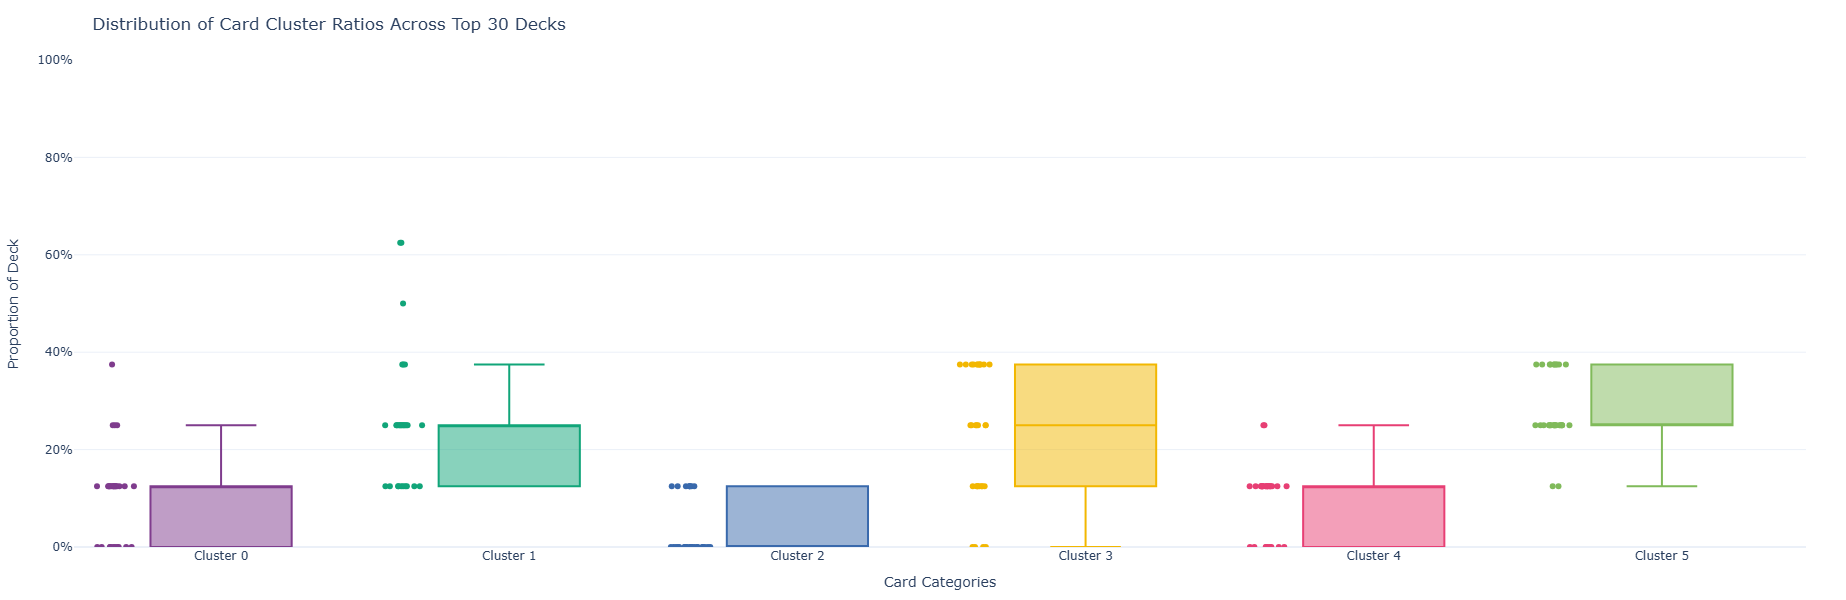

<Figure size 640x480 with 0 Axes>

In [9]:
# Create the box plot using the long-form ratio data
fig = px.box(
    df_long,
    x='Cluster',
    y='Ratio',
    color='Cluster',
    points="all",
    title='Distribution of Card Cluster Ratios Across Top 30 Decks',
    labels={'Ratio': 'Proportion of Deck', 'Cluster': 'Card Categories'},
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(
    yaxis_tickformat='.0%',
    yaxis=dict(range=[0, 1]),
    showlegend=False,
    height=600,
    margin=dict(l=60, r=40, t=60, b=40),
    template="plotly_white"
)

#plt.savefig('./graphs/card_type_ratio_box_plot.png')
fig.show()

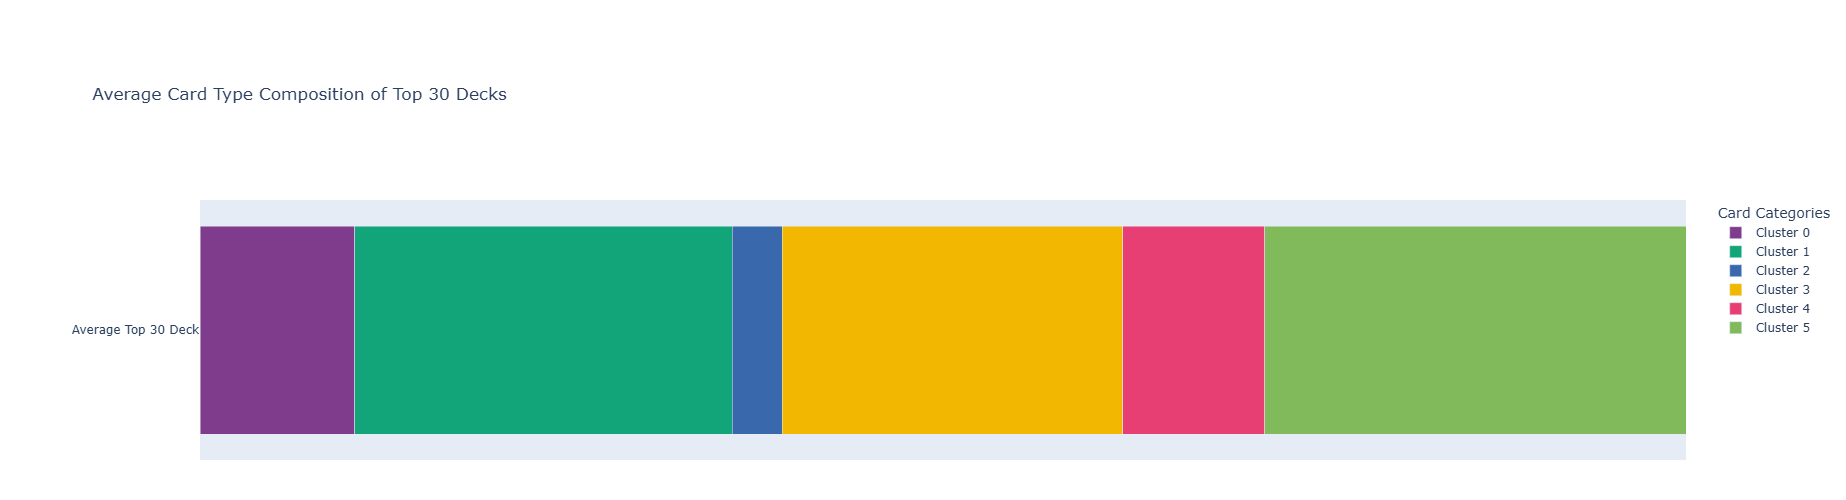

In [10]:
# Bar Chart of Averaged Deck Ratios (Single Horizontal Stacked Bar)
avg_ratios_series = cluster_ratios.iloc[:, :8].mean(numeric_only=True)

avg_df = pd.DataFrame([avg_ratios_series])

avg_df['Deck'] = "Average Top 30 Deck"

df_long = avg_df.melt(id_vars='Deck', var_name='Cluster', value_name='Ratio')

fig = px.bar(
    df_long, 
    x='Ratio', 
    y='Deck', 
    color='Cluster', 
    orientation='h',
    title='Average Card Type Composition of Top 30 Decks',
    labels={'Deck': ''},
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(
    barmode='stack',
    height=500,
    xaxis=dict(visible=False, range=[0, 1]),
    margin=dict(l=200, r=40, t=200, b=40),
    legend_title_text='Card Categories',
    hovermode='y unified'
)

#fig.write_html('./graphs/average_card_type_ratio.html')
fig.show()